# Quickstart

A 5-minute tour of the processed Freddie Mac dataset. Everything below runs against the parquet files under `data/processed/`, which you should already have on disk after `python scripts/download_data.py`.

The four loaders we'll use:

- `load_origination(years, columns=...)` — one row per loan, 34 columns.
- `load_outcomes(years)` — one row per loan, with `event_type` and `event_time_months`.
- `load_loans(years, columns=...)` — origination LEFT JOIN outcomes; features and event together.
- `load_monthly(years, columns=..., lazy=True)` — loan-month panel; prefer `lazy=True` and chain filters.
- `load_macro()` — monthly FRED series joined on `month`.

In [1]:
import sys
from pathlib import Path

# Add the repo root to sys.path so `from src.credit_data import ...` works.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import polars as pl
import matplotlib.pyplot as plt

from src.credit_data import load_origination, load_monthly, load_outcomes, load_macro

pl.Config.set_tbl_rows(8)
print("repo root:", REPO_ROOT)

repo root: c:\Users\a\Desktop\Credit\Project2


## 1. Origination — what's in a vintage

Pull a couple of vintages and look at the joint distribution of FICO, LTV, DTI, and rate at origination.

In [2]:
orig = load_origination(
    years=[2006, 2014, 2020],
    columns=["loan_seq_num", "vintage_year", "vintage_quarter", "fico", "ltv", "cltv", "dti", "orig_rate", "orig_upb", "state", "channel"],
)
print("shape:", orig.shape)
orig.head()

shape: (4695175, 11)


loan_seq_num,vintage_year,vintage_quarter,fico,ltv,cltv,dti,orig_rate,orig_upb,state,channel
str,u16,u8,u16,u8,u8,u8,f32,f32,str,str
"""F06Q10000001""",2006,1,768,75,75,null,6.5,130000.0,"""MI""","""R"""
"""F06Q10000002""",2006,1,779,80,80,31,6.25,214000.0,"""MI""","""R"""
"""F06Q10000003""",2006,1,713,77,77,35,6.375,81000.0,"""OH""","""R"""
"""F06Q10000004""",2006,1,767,67,67,64,6.0,175000.0,"""ND""","""R"""
"""F06Q10000005""",2006,1,778,80,80,33,6.25,296000.0,"""MI""","""R"""


In [3]:
# Means of the underwriting features by vintage — a quick credit-quality snapshot.
(
    orig.group_by("vintage_year")
    .agg([
        pl.len().alias("n_loans"),
        pl.col("fico").mean().round(0).alias("fico_mean"),
        pl.col("ltv").mean().round(1).alias("ltv_mean"),
        pl.col("dti").mean().round(1).alias("dti_mean"),
        pl.col("orig_rate").mean().round(2).alias("rate_mean"),
    ])
    .sort("vintage_year")
)

vintage_year,n_loans,fico_mean,ltv_mean,dti_mean,rate_mean
u16,u32,f64,f64,f64,f32
2006,1007663,722.0,71.8,37.1,6.44
2014,848732,747.0,78.2,34.3,4.48
2020,2838780,758.0,73.4,33.7,3.19


## 2. Outcomes — prepayment and default by vintage

`outcomes/` is small (~70 MB total), so it's safe to load every vintage at once. `event_type` is one of `prepaid` / `defaulted` / `other_termination` / `censored`.

In [4]:
out = load_outcomes()
print("shape:", out.shape)

rates = (
    out.group_by("vintage_year")
    .agg([
        pl.len().alias("n"),
        (pl.col("event_type") == "prepaid").mean().alias("prepay_rate"),
        (pl.col("event_type") == "defaulted").mean().alias("default_rate"),
        (pl.col("event_type") == "censored").mean().alias("censored_rate"),
    ])
    .sort("vintage_year")
)
rates

shape: (25186989, 10)


vintage_year,n,prepay_rate,default_rate,censored_rate
u16,u32,f64,f64,f64
2006,1007663,0.854161,0.11478,0.024133
2007,1069929,0.83205,0.131826,0.027245
2008,1022146,0.889349,0.07735,0.026646
2009,1712593,0.915133,0.01894,0.062757
…,…,…,…,…
2022,1351673,0.046055,0.003623,0.946755
2023,428718,0.014651,0.000075,0.984255
2024,970491,0.086055,0.002235,0.908641
2025,575529,0.017996,0.000019,0.981466


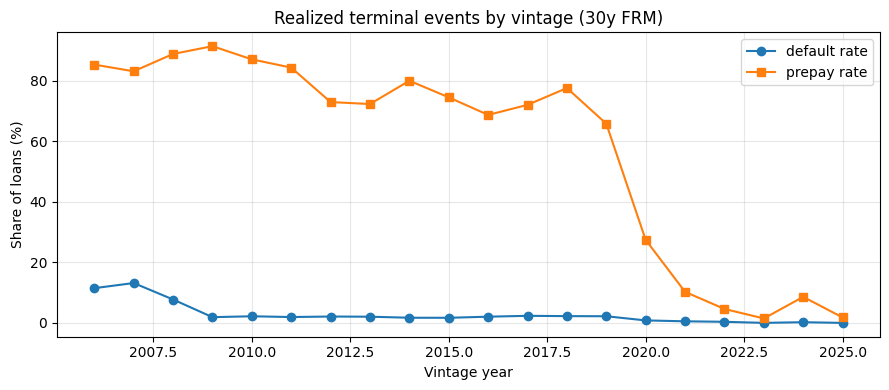

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
rates_pd = rates.to_pandas()
ax.plot(rates_pd["vintage_year"], rates_pd["default_rate"] * 100, marker="o", label="default rate")
ax.plot(rates_pd["vintage_year"], rates_pd["prepay_rate"] * 100, marker="s", label="prepay rate")
ax.set_xlabel("Vintage year")
ax.set_ylabel("Share of loans (%)")
ax.set_title("Realized terminal events by vintage (30y FRM)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Vintages closer to today are still mostly censored — they haven't had time to pay off or default — which is what makes 2024-2025 useful as held-out test data.

## 3. Features + outcome in one frame

For per-loan modeling (cross-sectional default/prepay classifiers, Cox feature builds, descriptive cuts), `load_loans()` returns origination LEFT JOIN outcomes on `loan_seq_num` — one row per loan with both the features known at t=0 (X) and the realized event (y).

The two tables stay separate on disk; this just hides the join. See [DATA.md](../DATA.md) for the rationale.

In [6]:
from src.credit_data import load_loans

loans = load_loans(
    years=[2006, 2010, 2014, 2020],
    columns=['loan_seq_num', 'vintage_year', 'fico', 'ltv', 'dti',
             'orig_rate', 'orig_upb', 'channel',
             'event_type', 'event_time_months'],
)
print('shape:', loans.shape)
loans.head()

shape: (5840405, 10)


loan_seq_num,vintage_year,fico,ltv,dti,orig_rate,orig_upb,channel,event_type,event_time_months
str,u16,u16,u8,u8,f32,f32,str,str,u16
"""F06Q10000001""",2006,768,75,null,6.5,130000.0,"""R""","""prepaid""",38
"""F06Q10000002""",2006,779,80,31,6.25,214000.0,"""R""","""prepaid""",35
"""F06Q10000003""",2006,713,77,35,6.375,81000.0,"""R""","""prepaid""",74
"""F06Q10000004""",2006,767,67,64,6.0,175000.0,"""R""","""prepaid""",15
"""F06Q10000005""",2006,778,80,33,6.25,296000.0,"""R""","""prepaid""",51


In [7]:
# Default rate as a function of origination FICO bucket — a 3-line analysis
# that needed both the feature (FICO) and the label (event_type).
fico_buckets = (
    loans.with_columns(pl.col('fico').cut([620, 660, 700, 740, 780]).alias('fico_band'))
    .group_by(['vintage_year', 'fico_band'])
    .agg([
        pl.len().alias('n'),
        (pl.col('event_type') == 'defaulted').mean().alias('default_rate'),
    ])
    .sort(['vintage_year', 'fico_band'])
)
fico_buckets

vintage_year,fico_band,n,default_rate
u16,enum,u32,f64
2006,null,833,0.081633
2006,"""(-inf, 620]""",44404,0.239258
2006,"""(620, 660]""",118237,0.21829
2006,"""(660, 700]""",191949,0.16022
…,…,…,…
2020,"""(660, 700]""",250330,0.020097
2020,"""(700, 740]""",564566,0.012477
2020,"""(740, 780]""",942781,0.006611
2020,"""(780, inf]""",1022109,0.003004


## 4. Monthly — pulling one loan's full history

The monthly panel is large (~9 GB), so always pass `lazy=True` and chain a filter before `.collect()`. Here we pick one defaulted loan and look at its actual UPB and delinquency status month-by-month.

In [8]:
# Pick the first defaulted 2006Q1 loan as an example.
example_id = (
    out.filter((pl.col("vintage_year") == 2006) & (pl.col("event_type") == "defaulted"))
    .head(1)
    .row(0, named=True)
)
print("example loan:", example_id["loan_seq_num"], "event_time_months=", example_id["event_time_months"])

lf = load_monthly(
    years=[2006],
    columns=["loan_seq_num", "month", "actual_upb", "dq_status", "current_rate", "zb_code"],
    lazy=True,
)
history = (
    lf.filter(pl.col("loan_seq_num") == example_id["loan_seq_num"])
    .sort("month")
    .collect()
)
history.tail(10)

example loan: F06Q10000008 event_time_months= 34


loan_seq_num,month,actual_upb,dq_status,current_rate,zb_code
str,date,f32,str,f32,str
"""F06Q10000008""",2010-12-01,230469.484375,"""10""",4.375,null
"""F06Q10000008""",2011-01-01,230469.484375,"""11""",4.375,null
"""F06Q10000008""",2011-02-01,230469.484375,"""12""",4.375,null
"""F06Q10000008""",2011-03-01,230469.484375,"""13""",4.375,null
…,…,…,…,…,…
"""F06Q10000008""",2011-06-01,230469.484375,"""16""",4.375,null
"""F06Q10000008""",2011-07-01,230469.484375,"""17""",4.375,null
"""F06Q10000008""",2011-08-01,230469.484375,"""18""",4.375,null
"""F06Q10000008""",2011-09-01,0.0,"""19""",4.375,"""02"""


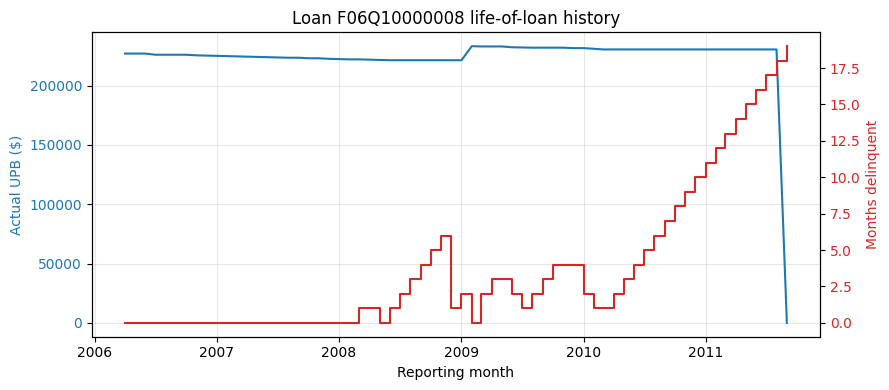

In [9]:
h = history.to_pandas()
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(h["month"], h["actual_upb"], color="tab:blue", label="actual UPB")
ax1.set_ylabel("Actual UPB ($)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
dq_int = h["dq_status"].apply(lambda s: int(s) if s and str(s).isdigit() else None)
ax2.step(h["month"], dq_int, color="tab:red", where="post", label="delinquency (months)")
ax2.set_ylabel("Months delinquent", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title(f"Loan {example_id['loan_seq_num']} life-of-loan history")
ax1.set_xlabel("Reporting month")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Kaplan-Meier prepayment curves by vintage

`event_time_months` is already in `outcomes/`, so building a KM is a one-liner per vintage. Here we treat **prepayment** as the event of interest and everything else (default / other / censored) as censored.

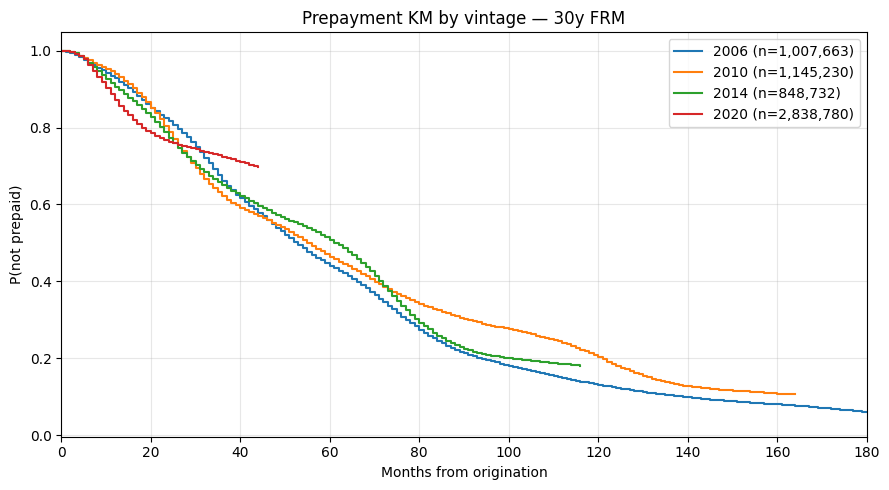

In [10]:
from lifelines import KaplanMeierFitter

fig, ax = plt.subplots(figsize=(9, 5))
for year in [2006, 2010, 2014, 2020]:
    df = (
        out.filter(pl.col("vintage_year") == year)
        .select(["event_time_months", "event_type"])
        .drop_nulls()
        .to_pandas()
    )
    if df.empty:
        continue
    df["observed_prepay"] = (df["event_type"] == "prepaid").astype(int)
    KaplanMeierFitter().fit(
        df["event_time_months"], df["observed_prepay"], label=f"{year} (n={len(df):,})"
    ).plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("Months from origination")
ax.set_ylabel("P(not prepaid)")
ax.set_title("Prepayment KM by vintage — 30y FRM")
ax.set_xlim(0, 180)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Joining macro features to the monthly panel

`load_macro()` returns one row per month with `MORTGAGE30US`, `GS10`, `UNRATE`, `CPIAUCSL`, `CSUSHPISA`. Join on `month`.

In [11]:
macro = load_macro().with_columns(pl.col("month").cast(pl.Date))
macro.tail(6)

month,MORTGAGE30US,GS10,UNRATE,CPIAUCSL,CSUSHPISA
date,f64,f64,f64,f64,f64
2025-11-01,6.2375,4.09,4.5,325.063,330.073
2025-12-01,6.19,4.14,4.4,326.031,331.258
2026-01-01,6.1025,4.21,4.3,326.588,331.801
2026-02-01,6.0475,4.13,4.4,327.46,332.098
2026-03-01,6.1775,4.25,4.3,330.293,null
2026-04-01,6.332,4.32,null,null,null


In [12]:
# A small, illustrative join: pick 5,000 active 2014 loans and attach macro features at each month.
sample_ids = (
    out.filter(pl.col("vintage_year") == 2014).head(5_000).select("loan_seq_num")
)
panel = (
    load_monthly(years=[2014], columns=["loan_seq_num", "month", "current_rate", "actual_upb"], lazy=True)
    .join(sample_ids.lazy(), on="loan_seq_num", how="semi")
    .join(macro.lazy(), on="month", how="left")
    .collect()
)
print("joined panel:", panel.shape)
panel.head()

joined panel: (300631, 9)


loan_seq_num,month,current_rate,actual_upb,MORTGAGE30US,GS10,UNRATE,CPIAUCSL,CSUSHPISA
str,date,f32,f32,f64,f64,f64,f64,f64
"""F14Q10000004""",2014-03-01,5.25,107000.0,4.3425,2.72,6.7,236.028,163.074
"""F14Q10000004""",2014-04-01,5.25,107000.0,4.3375,2.71,6.2,236.468,163.376
"""F14Q10000004""",2014-05-01,5.25,106000.0,4.192,2.56,6.3,236.918,163.641
"""F14Q10000004""",2014-06-01,5.25,106000.0,4.1625,2.6,6.1,237.231,164.048
"""F14Q10000004""",2014-07-01,5.25,106000.0,4.13,2.54,6.2,237.498,164.572


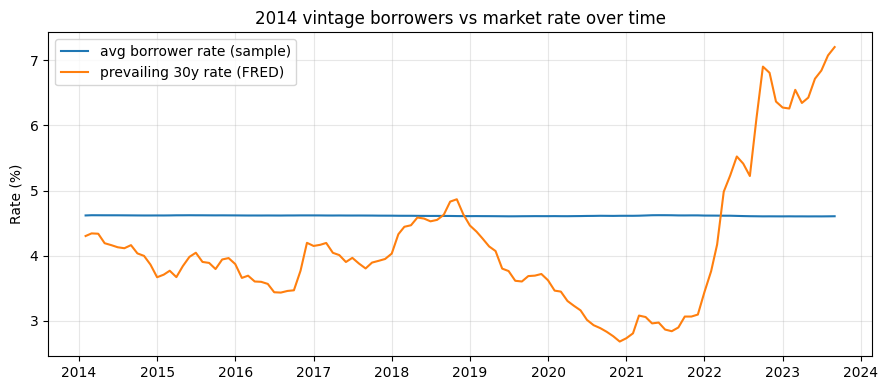

In [13]:
# Rate-incentive proxy: borrower's note rate minus the prevailing 30y mortgage rate.
agg = (
    panel.with_columns((pl.col("current_rate") - pl.col("MORTGAGE30US")).alias("rate_incentive"))
    .group_by("month")
    .agg([
        pl.col("current_rate").mean().alias("borrower_rate"),
        pl.col("MORTGAGE30US").first().alias("market_rate"),
        pl.col("rate_incentive").mean().alias("rate_incentive"),
    ])
    .sort("month")
)
agg_pd = agg.to_pandas()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(agg_pd["month"], agg_pd["borrower_rate"], label="avg borrower rate (sample)")
ax.plot(agg_pd["month"], agg_pd["market_rate"], label="prevailing 30y rate (FRED)")
ax.set_ylabel("Rate (%)")
ax.set_title("2014 vintage borrowers vs market rate over time")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Where to go from here

- **Cox regression / time-varying covariates** — `lifelines.CoxPHFitter` and `CoxTimeVaryingFitter` both consume the long format produced by joining `monthly/` with `macro`.
- **XGBoost survival** — `xgboost.XGBSurvivalAnalysis` on `(event_time_months, event_observed)` from `outcomes/`.
- **Treat 2024-2025 as held-out test** — the README documents why; train on 2006-2022 and evaluate on 2024-2025.